In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import subprocess
from enum import IntEnum, auto
from pathlib import Path
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter

from Analysis import fluc, FaStep
from Extraction import extract, ResolutionMode
from Settings import settings, Setting, parameter, NLD
from Simulation import sim
from Func import func
#MEHR STATISTIK!!!!

In [8]:
runs = sim.read_folder(Path(r"C:\FAIRIES output\RUNS\EVENTITER"))

In [ ]:

fluc.plot.clear_folders()
fluc.plot.create(runs,Setting.g_nEvent,res_mode=ResolutionMode.percentage,plot_fit_line=True)

In [9]:
event_axis, dev_axis = fluc.deviation_axes(runs, res_mode=ResolutionMode.percentage)

c:\Users\Bonsaibäumchen\Desktop\bachelorarbeit\fluctuation_analysis\Analysis.py:516: RuntimeWarning: invalid value encountered in divide
  stationary = fine/rough


[ 1.78388514 -3.69009937]
[ 1.03348705 -0.82941028]
[ 1.41775926 -2.25839137]
[ 1.56311113 -2.91979525]
[ 1.46847629 -2.54963311]
[ 1.2873879  -1.99849016]
[ 1.16994017 -1.63211311]
[ 1.26186552 -1.55447103]
[ 1.08096913 -1.06533589]
[ 1.40808606 -2.31017043]
[ 1.18805682 -1.45820946]
[ 1.26325843 -1.87992423]
[ 0.91220631 -0.71960324]
[ 1.11782163 -1.36488541]
[ 1.33658412 -2.32725081]
[ 0.84127214 -0.32757989]
[ 1.11812019 -1.30273275]
[ 0.88810703 -0.23564006]
[ 1.0031398  -0.94332663]
[ 0.85852434 -0.35249426]
[ 1.03536029 -0.92778509]
[ 1.43306199 -2.27153916]
[ 1.19136524 -1.29913558]
[ 1.10319716 -1.18373373]
[ 1.57026805 -2.82226348]
[ 1.65175639 -2.86747161]
[ 1.4996207  -2.41776912]
[ 1.20190739 -1.3330822 ]
[ 1.23087482 -1.60808026]
[ 1.25161212 -1.85019943]
[ 1.4585108  -2.39302455]
[ 0.96402832 -0.89585494]
[ 1.3183675  -2.05066793]
[ 1.14899042 -1.19865553]
[ 1.17718617 -1.43051745]
[ 1.32323995 -1.67097037]
[ 0.9585928  -0.88925295]
[ 1.07412678 -1.23718477]
[ 1.18297204

In [12]:
dev_mean = np.mean(dev_axis)
rounded_mean = round(dev_mean*100,2)
rounded_mean
error = np.std(dev_axis, ddof=1)
rounded_error = round(error*100,2)
(rounded_mean,rounded_error)

(np.float64(92.09), np.float64(34.03))

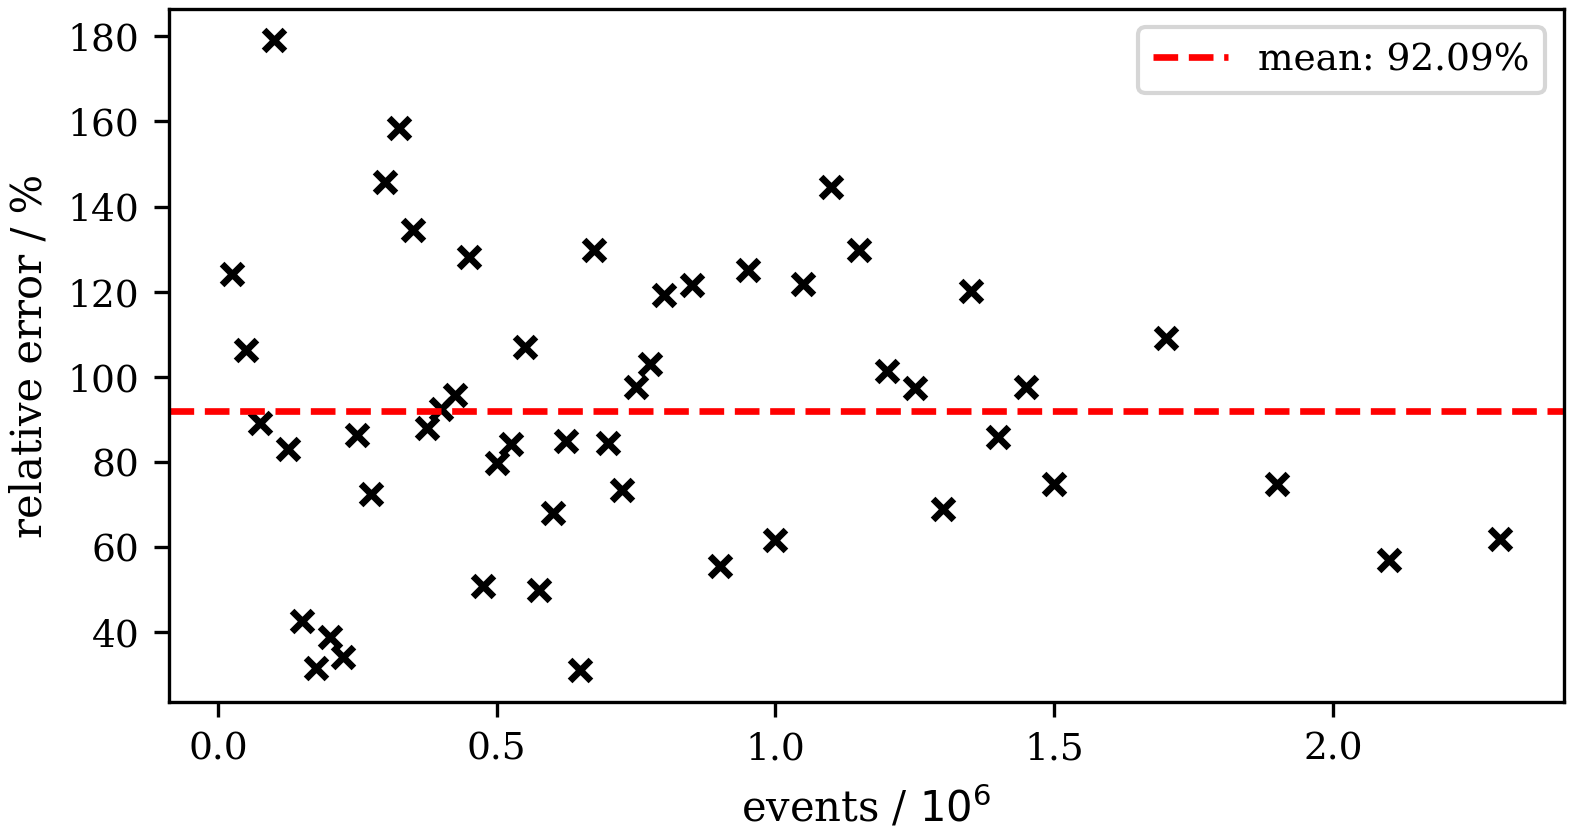

In [11]:
fluc.plot.plot_values_set()
plt.figure(figsize=(6,3))
plt.scatter([event * 1e-6 for event in event_axis], [dev * 100 for dev in dev_axis],marker="x",color="black")
plt.axhline(y=rounded_mean, color='red', linestyle='--', label="mean: "+str(rounded_mean)+"%")
plt.legend()
plt.xlabel(r"events / $10^6$")
plt.ylabel("relative error / %")
plt.savefig(settings.std_path / settings.folder_comparison_name / "deviation.png", dpi=300)

In [2]:
run = sim.read_run(Path(r"C:\FAIRIES output\RUNS\EVENTITER\g_nEvent_500000"))

In [3]:
parameter[Setting.exp_resolution] = 0.003
fluc.plot.create([run],Setting.g_nEvent, res_mode=ResolutionMode.percentage,plot_fit_line=True)

c:\Users\Bonsaibäumchen\Desktop\bachelorarbeit\fluctuation_analysis\Analysis.py:516: RuntimeWarning: invalid value encountered in divide
  stationary = fine/rough


[ 1.14899042 -1.19865553]


In [5]:
actm = 1/(func.CTM_temp*np.log(10))
asim = 1.14899042
abs(asim-actm)/actm

np.float64(0.7974004830056655)

In [ ]:
sim.parallel.iterate(range(25000,825000,50000), max_workers=10,save_path=Path(r"C:\FAIRIES output\RUNS\EVENTITER"))

In [ ]:
sim.parallel.iterate(range(1700000,2400000,200000), max_workers=10,save_path=Path(r"C:\FAIRIES output\RUNS\EVENTITER"))

In [ ]:
# runs = sim.read_folder(Path(r"C:\FAIRIES output\RUNS\EVENTITER"))
# fa = fluc.fluctuation_analysis(runs[0],res_mode=ResolutionMode.percentage)
# energy = fa.fluct_energy
# dist = sim.pop.dist_normed(energy, settings.Q_76Ga)
# plt.figure(figsize=(6,2.5))
# plt.plot(energy,[d * 100 for d in dist])
# plt.xlabel("E / MeV")
# plt.ylabel("pop. probability / %")

In [ ]:
runs = sim.read_folder(settings.run_folder / "WENDUNG")

In [ ]:
parameter[Setting.exp_resolution] = 0.003
print((1/func.CTM_temp))
fluc.plot.clear_folders()
fluc.plot.create(runs,Setting.g_nEvent,res_mode=ResolutionMode.,plot_fit_line=True)

In [ ]:
fluc.plot.clear_folders()
fluc.plot.iter_analysis_param(
    run,
    Setting.exp_resolution,
    [0.050],
    res_mode=ResolutionMode.percentage,
    plot_single=False,
    plot_fit_line=True
    )

In [ ]:
runs = sim.read_folder(Path(r"C:\FAIRIES output\RUNS\Try"))

In [ ]:
fluc.plot.clear_folders()
fluc.plot.create(runs, Setting.g_nEvent)

In [ ]:
runs = sim.read_folder(settings.run_folder / "Try")

In [ ]:
fluc.plot.clear_folders()
fluc.plot.create(runs, Setting.g_nEvent)

In [ ]:
sim.parallel.run(events=50000000, max_workers=10,save_path=settings.run_folder / "WENDUNG")

In [ ]:
plt.rcParams.update({
    # Font
    "font.family": "serif",
    "font.size": 10,

    # Axes
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Legend
    "legend.fontsize": 9,

    # Lines
    "lines.linewidth": 1.6,
    "lines.markersize": 5,

    # Figure
    "figure.dpi": 300,

    # Saving
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
})

In [ ]:
run = sim.read_run(Path(r"C:\FAIRIES output\RUNS\WENDUNG\g_nEvent_5000000"))

In [ ]:
runs = sim.read_folder(Path(r"C:\FAIRIES output\RUNS\WENDUNG"))

In [ ]:
fluc.plot.clear_folders()
fluc.plot.create(runs,Setting.g_nEvent)

In [ ]:
nld_energy, nld_dict = run.level_data
nld = nld_dict["-1"]

In [ ]:
fa = fluc.fluctuation_analysis(nld_energy, nld)
fluc.plot.clear_folders()
fluc.plot.create_by_fa(fa, file_name="", log_scale=True, figsize=(6,2.5))

In [ ]:
runs = sim.read_folder(settings.run_folder / "LAST")

In [ ]:
# parameter[Setting.exp_resolution] = 0.003
# fluc.plot.create(runs,Setting.g_nEvent)

In [ ]:
run = runs[-1]
print(run.settings[Setting.g_nEvent])

In [ ]:
run = sim.read_run(Path(r"C:\FAIRIES output\RUNS\WENDUNG\g_nEvent_5000000"))

In [ ]:
fluc.plot.clear_folders()
fluc.plot.iter_analysis_param(run, Setting.exp_resolution, np.arange(0.003, 0.05, 0.009))

In [ ]:
sim.parallel.run(events=7500000,max_workers=10, save_path=settings.this_dir)

In [ ]:
sim.parallel.run(events=750000,max_workers=10, save_path=settings.this_dir)